--- Loading Data ---
✅ Loaded appendicitis: 957 pairs
✅ Loaded cholecystitis: 648 pairs
✅ Loaded diverticulitis: 257 pairs
✅ Loaded pancreatitis: 538 pairs

Total Pooled Records: 2400


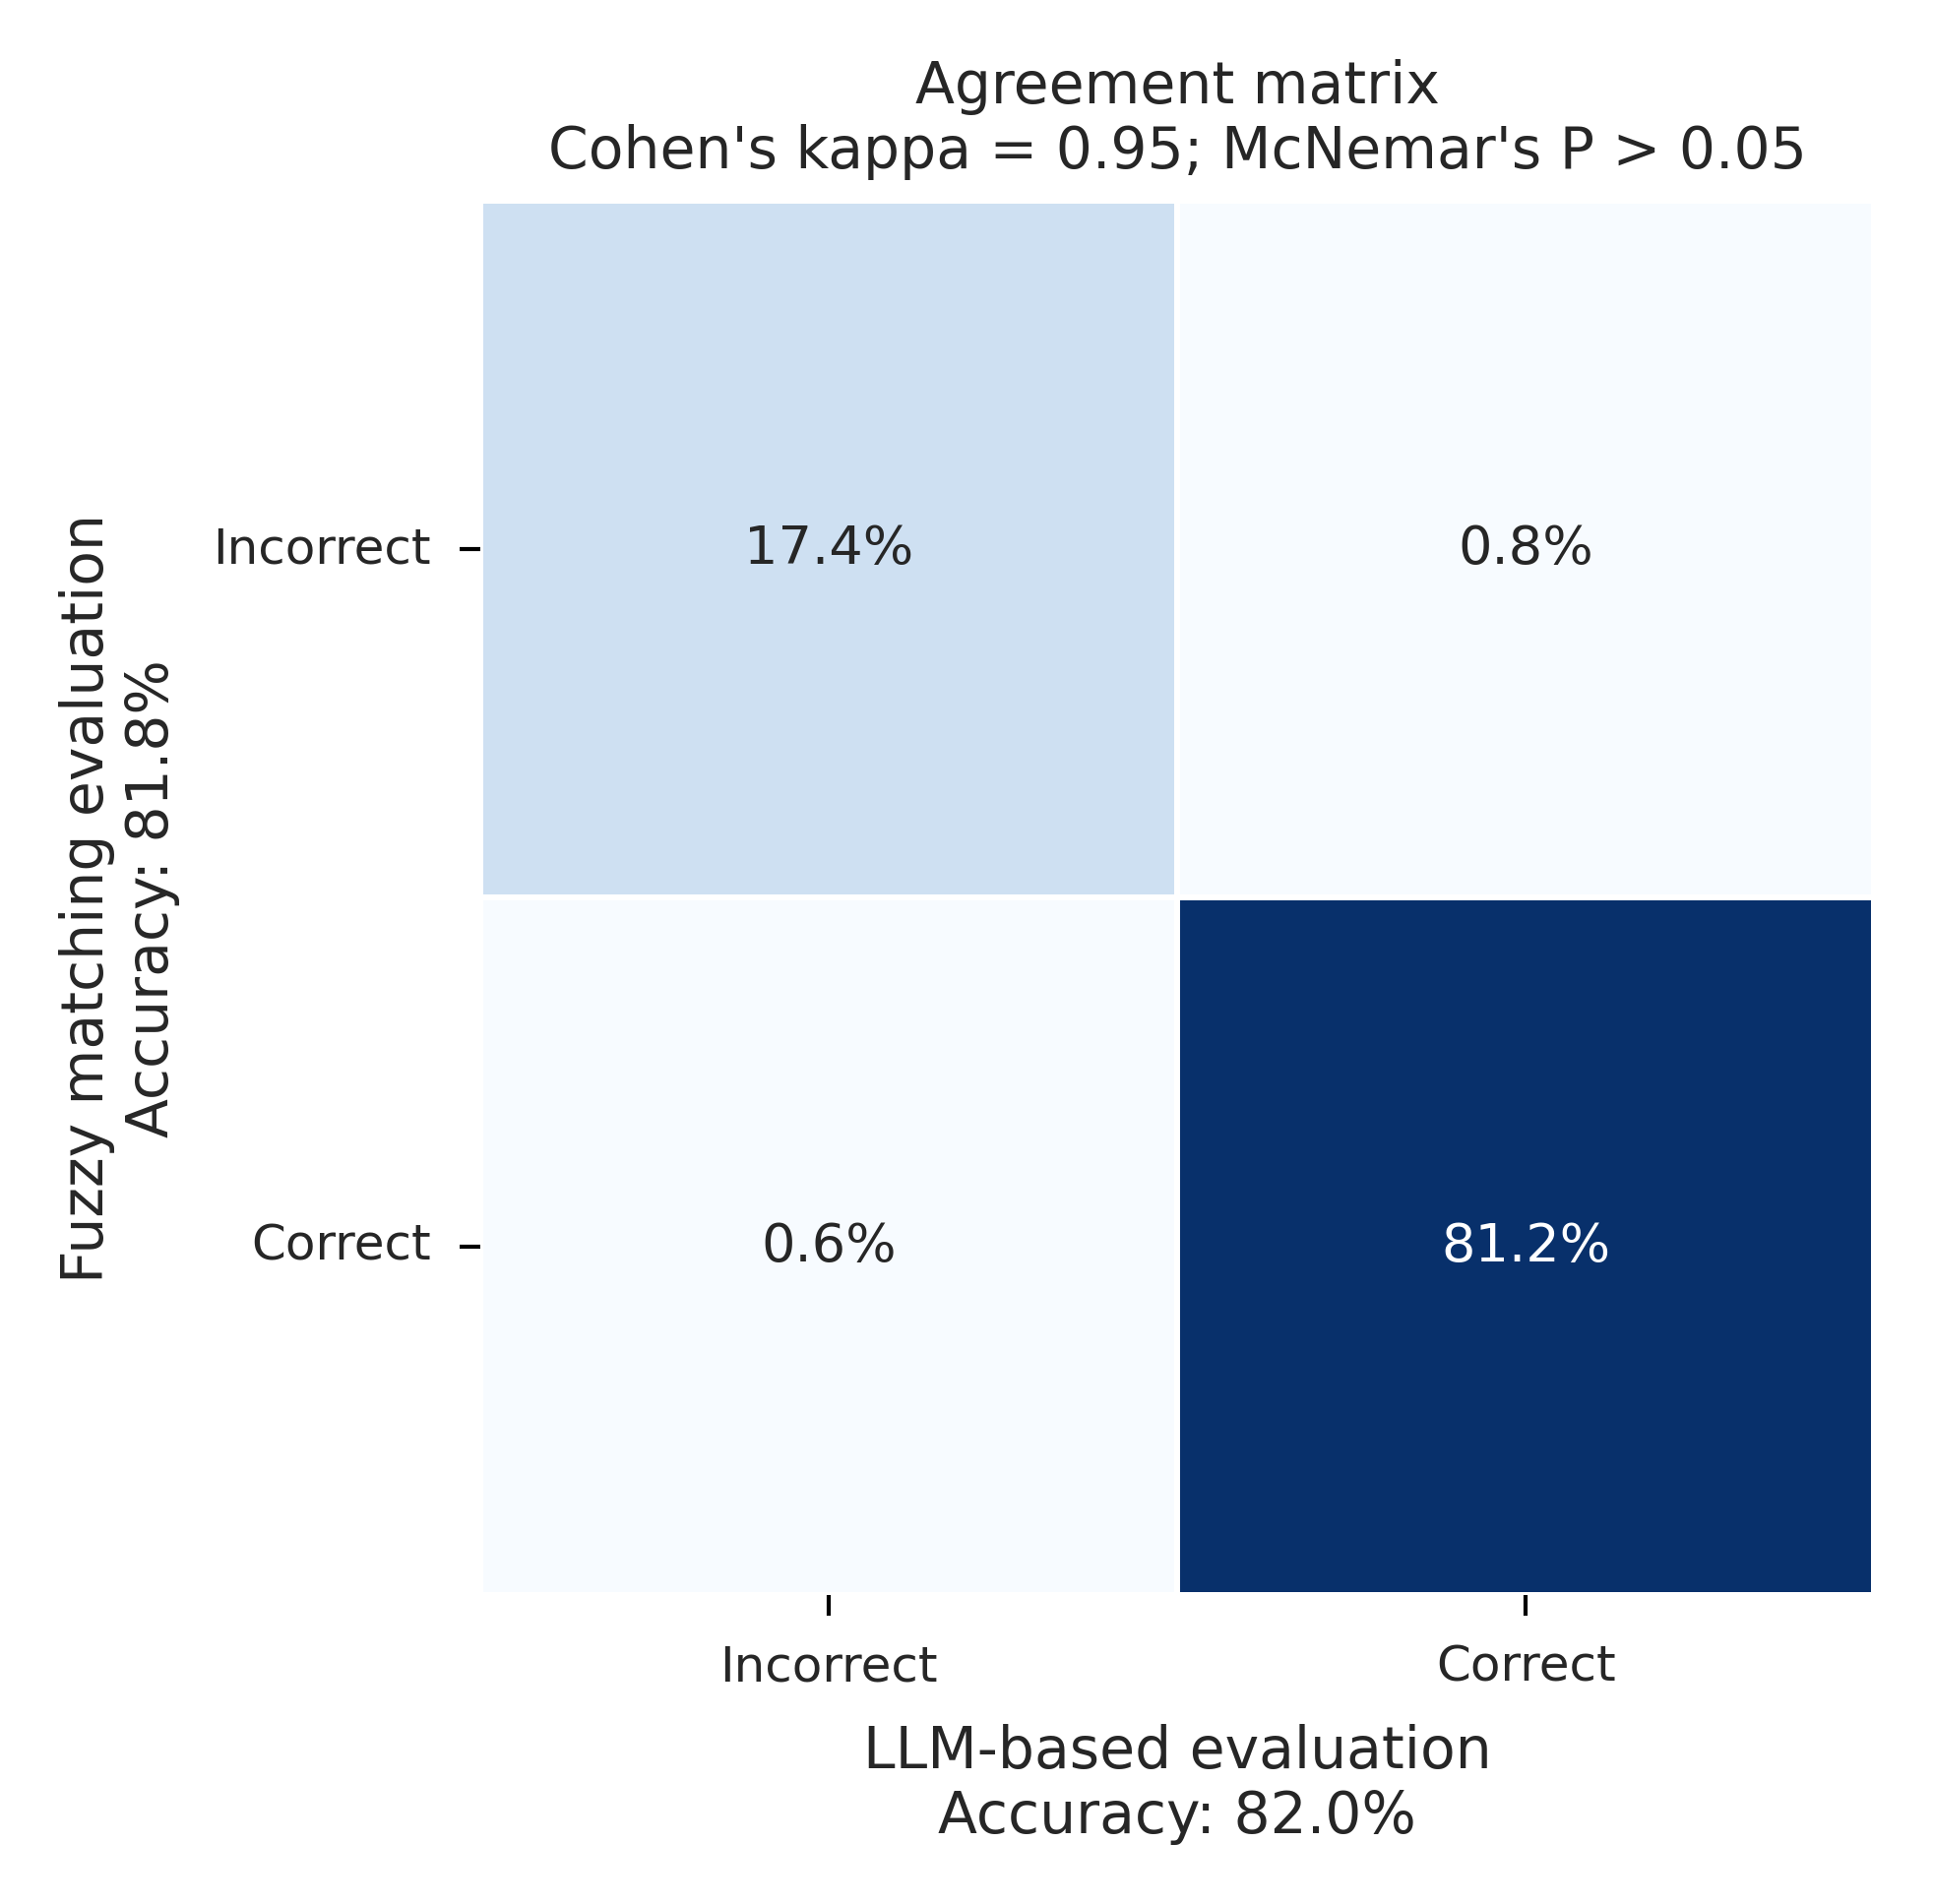

Saved Nature-style figure to /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/55_clean/LLM_vs_Fuzzy/Fig_S1_Evaluation_Comparison.svg


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar

# ================= Configuration =================
# Four CDM disease names (adjust to match your folder names).
diseases = [
    "appendicitis", 
    "cholecystitis", 
    "diverticulitis", 
    "pancreatitis"
]

# Base path configuration
# Root directory for LLM results (contains disease folders)
llm_base_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/55_clean/55.10/run_1"

# Root directory for Fuzzy results (adjust the structure as needed)
fuzzy_base_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/55_clean/run_1"

output_dir = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/55_clean/LLM_vs_Fuzzy"

# ================= 1. Batch loading and merging =================
def load_all_diseases(diseases, llm_base, fuzzy_base):
    all_merged = []
    
    print("--- Loading Data ---")
    for disease in diseases:
        # 1. Construct paths (based on the supplied structure)
        # LLM: .../55.3/appendicitis/appendicitis_diagnosis_results.jsonl
        llm_path = os.path.join(llm_base, disease, f"{disease}_diagnosis_results.jsonl")
        
        # Fuzzy: .../run_1/appendicitis_diagnosis_results_fuzzy.jsonl
        fuzzy_path = os.path.join(fuzzy_base, f"{disease}_diagnosis_results_fuzzy.jsonl")
        
        if not os.path.exists(llm_path) or not os.path.exists(fuzzy_path):
            print(f"⚠️ Warning: Missing files for {disease}, skipping.")
            continue
            
        try:
            # 2. Read LLM results
            df_llm = pd.read_json(llm_path, lines=True)
            # Extract hadm_id and decision
            df_llm = df_llm[['hadm_id', 'decision']].rename(columns={'decision': 'LLM_Decision'})
            
            # 3. Read Fuzzy results
            df_fuzzy = pd.read_json(fuzzy_path, lines=True)
            # Extract hadm_id and gracious_diagnosis_score (1=True, 0=False)
            df_fuzzy['Fuzzy_Decision'] = df_fuzzy['gracious_diagnosis_score'].astype(bool)
            df_fuzzy = df_fuzzy[['hadm_id', 'Fuzzy_Decision']]
            
            # 4. Merge (inner join)
            df_merged = pd.merge(df_llm, df_fuzzy, on='hadm_id', how='inner')
            df_merged['disease'] = disease # Mark disease sources; retain them for reference even though plotting aggregates them.
            
            all_merged.append(df_merged)
            print(f"✅ Loaded {disease}: {len(df_merged)} pairs")
            
        except Exception as e:
            print(f"❌ Error loading {disease}: {e}")

    if not all_merged:
        raise ValueError("No data loaded!")
        
    # Merge all diseases into one table
    final_df = pd.concat(all_merged, ignore_index=True)
    return final_df

# ================= 2. Statistical tests (unchanged) =================
def calculate_stats(df):
    y_llm = df['LLM_Decision']
    y_fuzzy = df['Fuzzy_Decision']
    
    acc_llm = y_llm.mean()
    acc_fuzzy = y_fuzzy.mean()
    kappa = cohen_kappa_score(y_llm, y_fuzzy)
    
    # McNemar's Test
    conf_matrix = confusion_matrix(y_fuzzy, y_llm) 
    # exact=True is suitable for any sample size
    result = mcnemar(conf_matrix, exact=True)
    p_value = result.pvalue
    
    return acc_llm, acc_fuzzy, kappa, p_value, conf_matrix

# ================= 3. Plotting (fine-tuned details) =================
import matplotlib as mpl
from pathlib import Path

def set_new_style():
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "legend.title_fontsize": 6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
    })

def save_figure(fig, out_base):
    out_base = Path(out_base)
    fig.savefig(out_base.with_suffix(".svg"), bbox_inches="tight")
    fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(out_base.with_suffix(".png"), dpi=600, bbox_inches="tight")

def plot_comparison(df, stats, save_path):
    acc_llm, acc_fuzzy, kappa, p_val, conf_matrix = stats
    
    sns.set_style("white")
    # Fall back to sans-serif when Arial is unavailable
    plt.rcParams['font.family'] = 'sans-serif'
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), dpi=600)
    
    # --- Panel A: Accuracy Comparison ---
    ax1 = axes[0]
    methods = ['Fuzzy Matching', 'LLM-Based']
    accuracies = [acc_fuzzy * 100, acc_llm * 100]
    colors = ['#A9A9A9', '#4A90E2']
    
    bars = ax1.bar(methods, accuracies, color=colors, width=0.6, alpha=0.9, edgecolor='black', linewidth=0.5)
    
    ax1.set_ylim(0, 110) # Leave room for the P-value.
    ax1.set_ylabel('Diagnostic Accuracy (%)', fontsize=12, fontweight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
        
    # P-value line.
    h = max(accuracies) + 5
    ax1.plot([0, 0, 1, 1], [h, h+2, h+2, h], "k-", lw=1)
    
    p_text = "ns" if p_val > 0.05 else f"P={p_val:.3f}"
    # If P > 0.05, this is a favorable result (no significant difference)
    ax1.text(0.5, h+4, f"McNemar's P = {p_val:.3f} ({p_text})", 
             ha='center', va='bottom', fontsize=10)
    
    ax1.set_title('a. Accuracy Comparison (Pooled)', loc='left', fontsize=12, fontweight='bold')

    # --- Panel B: Agreement Matrix ---
    ax2 = axes[1]
    
    # Normalize to percentages
    conf_matrix_norm = conf_matrix / conf_matrix.sum()
    
    # Use a more refined blue
    sns.heatmap(conf_matrix_norm, annot=True, fmt='.1%', cmap="Blues", cbar=False,
                xticklabels=['Incorrect', 'Correct'], yticklabels=['Incorrect', 'Correct'],
                annot_kws={"size": 14, "weight": "bold"}, ax=ax2, linewidths=1, linecolor='white')
    
    ax2.set_xlabel('LLM-Based Evaluation', fontsize=11)
    ax2.set_ylabel('Fuzzy Matching Evaluation', fontsize=11)
    
    # Dynamically assess Kappa
    kappa_strength = ""
    if kappa > 0.8: kappa_strength = "(Almost Perfect)"
    elif kappa > 0.6: kappa_strength = "(Substantial)"
    
    ax2.set_title(f'b. Agreement Matrix\nKappa={kappa:.2f} {kappa_strength}', loc='left', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    print(f"✅ Plot saved to {save_path}")

def plot_comparison_new(df, stats, save_path):
    acc_llm, acc_fuzzy, kappa, p_val, conf_matrix = stats

    sns.set_style("white")
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "axes.linewidth": 0.5,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), dpi=600)
    
    # --- Panel A: Accuracy Comparison ---
    ax1 = axes[0]
    methods = ['Fuzzy Matching', 'LLM-Based']
    accuracies = [acc_fuzzy * 100, acc_llm * 100]
    colors = ['#A9A9A9', '#4A90E2']
    
    # avoid heavy black borders for cleaner bars
    bars = ax1.bar(methods, accuracies, color=colors, width=0.6, alpha=1.0,
                   edgecolor='none', linewidth=0.0)

    ax1.set_ylim(0, 110)  # Leave room for the P-value.
    ax1.set_ylabel('Diagnostic Accuracy (%)', fontsize=12)
    
    # remove top/right spines and use thin left/bottom spines
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_linewidth(0.5)
    ax1.spines['bottom'].set_linewidth(0.5)

    ax1.tick_params(axis='both', which='major', width=0.5, length=2.5, direction='out')

    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
        
    # P-value line (preserve the logic and make the line slightly thinner)
    h = max(accuracies) + 5
    # ax1.plot([0, 0, 1, 1], [h, h+2, h+2, h], "k-", lw=0.8)
    
    p_text = "ns" if p_val > 0.05 else f"P={p_val:.3f}"
    ax1.text(0.5, h+10, f"McNemar's P = {p_val:.3f} ({p_text})",
             ha='center', va='bottom', fontsize=9)
    
    # ax1.set_title('a. Accuracy Comparison (Pooled)', loc='left', fontsize=12, fontweight='bold')

    # --- Panel B: Agreement Matrix ---
    ax2 = axes[1]
    
    conf_matrix_norm = conf_matrix / conf_matrix.sum()
    
    sns.heatmap(
        conf_matrix_norm,
        annot=True,
        fmt='.1%',
        cmap="Blues",
        cbar=False,
        xticklabels=['Incorrect', 'Correct'],
        yticklabels=['Incorrect', 'Correct'],
        # keep annotations modest in size and weight
        annot_kws={"size": 10},
        ax=ax2,
        linewidths=1,
        linecolor='white',
        square=True
    )
    
    # remove top/right spines and use lighter ticks
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_linewidth(0.5)
    ax2.spines['bottom'].set_linewidth(0.5)
    ax2.tick_params(axis='both', which='major', width=0.5, length=2.5, direction='out')

    ax2.set_xlabel('LLM-Based Evaluation', fontsize=11)
    ax2.set_ylabel('Fuzzy Matching Evaluation', fontsize=11)
    ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)
    
    kappa_strength = ""
    if kappa > 0.8: kappa_strength = "(Almost Perfect)"
    elif kappa > 0.6: kappa_strength = "(Substantial)"
    
    ax2.set_title(f'b. Agreement Matrix\nKappa={kappa:.2f} {kappa_strength}',
                  loc='left', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    print(f"✅ Plot saved to {save_path}")

def plot_comparison_single(df, stats, save_path):
    acc_llm, acc_fuzzy, kappa, p_val, conf_matrix = stats
    
    sns.set_style("white")
    plt.rcParams['font.family'] = 'sans-serif'
    
    # Create a small, polished square canvas
    fig, ax = plt.subplots(figsize=(6, 5), dpi=600)
    
    # Normalize to percentages.
    conf_matrix_norm = conf_matrix / conf_matrix.sum()
    
    # Draw the heatmap
    sns.heatmap(conf_matrix_norm, annot=True, fmt='.1%', cmap="Blues", cbar=False,
                xticklabels=['Incorrect', 'Correct'], 
                yticklabels=['Incorrect', 'Correct'],
                annot_kws={"size": 16, "weight": "bold"}, 
                linewidths=1, linecolor='white',
                ax=ax)
    
    # Axis labels
    ax.set_xlabel(f'LLM-Based Evaluation\n(Accuracy: {acc_llm:.1%})', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Fuzzy Matching Evaluation\n(Accuracy: {acc_fuzzy:.1%})', fontsize=12, fontweight='bold')
    
    # Title includes the key statistic
    p_text = "ns" if p_val > 0.05 else f"P={p_val:.3f}"
    title_text = (f"Methodological Concordance Analysis\n"
                  f"Cohen's Kappa = {kappa:.2f} | McNemar's {p_text}")
    
    ax.set_title(title_text, loc='center', fontsize=13, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    print(f"✅ Single Plot saved to {save_path}")


def plot_comparison_single_new(df, stats, save_path):
    acc_llm, acc_fuzzy, kappa, p_val, conf_matrix = stats

    set_new_style()
    sns.set_style("white")

    # Single-column figure width: about 85-90 mm.
    fig_size = 80 / 25.4
    fig, ax = plt.subplots(figsize=(fig_size, fig_size), dpi=600)

    conf_matrix_norm = conf_matrix / conf_matrix.sum()

    sns.heatmap(
        conf_matrix_norm,
        annot=True,
        fmt=".1%",
        cmap="Blues",
        cbar=False,
        xticklabels=["Incorrect", "Correct"],
        yticklabels=["Incorrect", "Correct"],
        annot_kws={"size": 6.5, "weight": "normal"},
        linewidths=0.5,
        linecolor="white",
        square=True,
        ax=ax,
    )

    ax.set_xlabel(f"LLM-based evaluation\nAccuracy: {acc_llm:.1%}")
    ax.set_ylabel(f"Fuzzy matching evaluation\nAccuracy: {acc_fuzzy:.1%}")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    p_text = "P > 0.05" if p_val > 0.05 else f"P = {p_val:.3f}"
    ax.set_title(
        f"Agreement matrix\nCohen's kappa = {kappa:.2f}; McNemar's {p_text}",
        pad=4,
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=2.5,
        width=0.5,
        color="black",
        bottom=True,
        left=True,
    )

    for spine in ax.spines.values():
        spine.set_visible(False)
        # spine.set_linewidth(0.5)

    plt.tight_layout(pad=0.5)

    save_figure(fig, save_path)
    plt.show()

    print(f"Saved figure to {Path(save_path).with_suffix('.svg')}")

# ================= Execute =================
if __name__ == "__main__":
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Load and merge data for all diseases
    try:
        final_df = load_all_diseases(diseases, llm_base_dir, fuzzy_base_dir)
        print(f"\nTotal Pooled Records: {len(final_df)}")
        
        # 2. Calculate statistics
        stats = calculate_stats(final_df)
        
        # 3. Plot
        save_file = os.path.join(output_dir, "Fig_S1_Evaluation_Comparison.svg")
        # plot_comparison(final_df, stats, save_file)
        # plot_comparison_new(final_df, stats, save_file)
        # plot_comparison_single(final_df, stats, save_file)
        plot_comparison_single_new(final_df, stats, save_file)
        
    except Exception as e:
        print(f"Program failed: {e}")